# **M3 - Discovering Latent Musical Structure Using Spotify Audio Features**

CS 4412 - Data Mining

This project analyzes a dataset of 114,000 Spotify tracks to discover latent musical patterns using data mining techniques.

Techniques used:
- Exploratory Data Analysis
- PCA (Dimensionality Reduction)
- K-Means Clustering
- DBSCAN Clustering
- Local Outlier Factor (Anomaly Detection)

The goal is to identify natural groupings of songs and detect unusual musical patterns.

# **Discovery Question**

Can unsupervised learning techniques (PCA, K-Means, and DBSCAN) uncover meaningful latent structures in Spotify audio features, and what distinct musical patterns or song groupings emerge from these features?

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

from sklearn.neighbors import LocalOutlierFactor

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/CS4412_Project/"

df = pd.read_csv(data_path + "Spotify_Tracks_Dataset.csv")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df = df.drop(columns=["Unnamed: 0"])

### Data Preprocessing

Before applying dimensionality reduction and clustering techniques, the dataset was preprocessed to ensure meaningful and reliable results.

### Feature Selection
Only relevant numerical audio features were selected for analysis, including attributes such as danceability, energy, loudness, acousticness, and tempo. These features capture key musical characteristics of each track. Non-numerical columns (e.g., track name, artist) and identifiers were excluded, as they do not contribute to clustering.

### Feature Scaling
The selected features were standardized using `StandardScaler` to ensure that all variables are on the same scale. This is important because clustering algorithms like K-Means and distance-based methods such as DBSCAN rely on distance calculations. Without scaling, features with larger ranges (e.g., duration) would dominate the analysis and bias the results.

### Dimensionality Preparation
After scaling, the data was prepared for dimensionality reduction using PCA. This step helps reduce redundancy among correlated features and allows for easier visualization of latent structures in lower-dimensional space.

# Data Overview

In [ ]:
df.shape

(114000, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [ ]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,cluster,dbscan_cluster,anomaly
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035,0.870737,9.487719,0.960579
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621,0.730151,46.234098,0.278009
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000,0.000000,-1.000000,1.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,1.000000,-1.000000,1.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000,1.000000,0.000000,1.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,2.000000,351.000000,1.000000


# Data Overview Interpretation

The dataset contains 114,000 tracks with 21 features, including both numerical and categorical variables. Most features are complete with minimal missing values, indicating high data quality. The numerical features such as energy, danceability, and tempo appear to have reasonable distributions for analysis.

# Data Quality Assessment

In [ ]:
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [ ]:
df.duplicated().sum()

np.int64(450)

# Data Quality Interpretation


The dataset contains almost no missing values and no duplicate entries, indicating that it is clean and suitable for analysis. Only a few categorical fields had minor missing values, which do not significantly impact the modeling process.

# Exploratory Data Analysis (EDA)

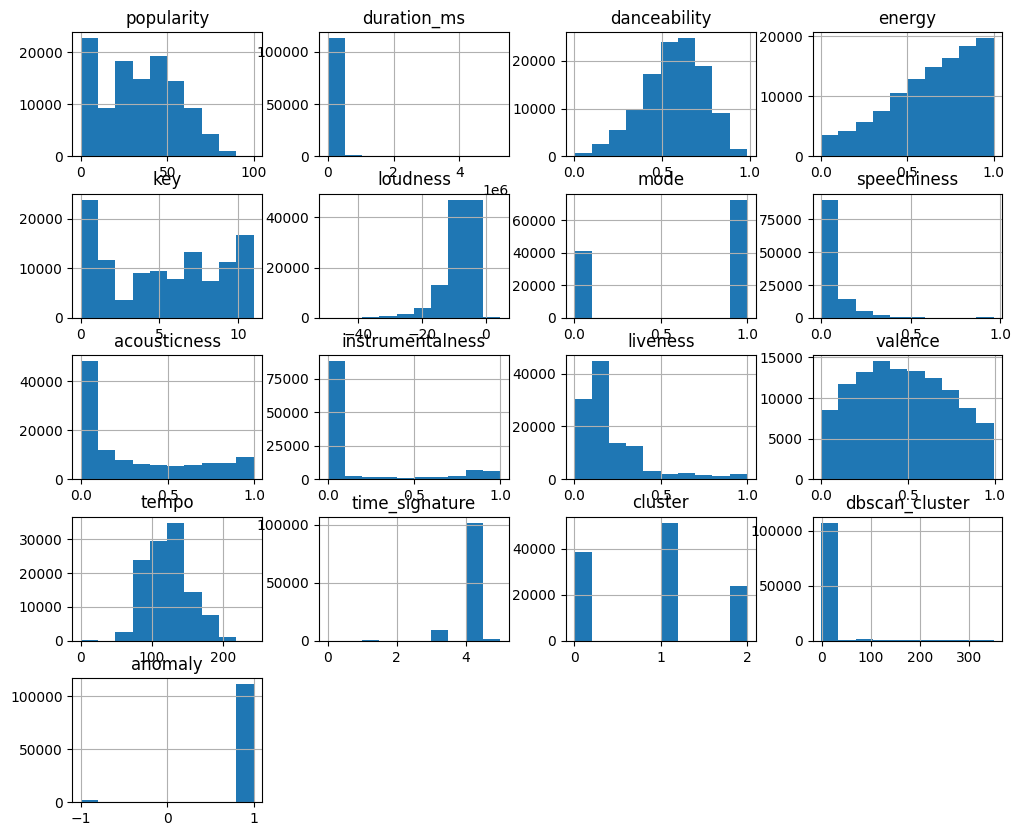

In [ ]:
# Exploratory Data Analysis (EDA)

df.hist(figsize=(12,10))
plt.show()

# Exploratory Data Analysis (EDA) Interpretation

The feature distributions reveal that many variables such as speechiness and instrumentalness are highly skewed, while others like danceability and energy are more normally distributed. This suggests that songs vary widely in certain characteristics but are more consistent in others.

# Correlation Heatmap

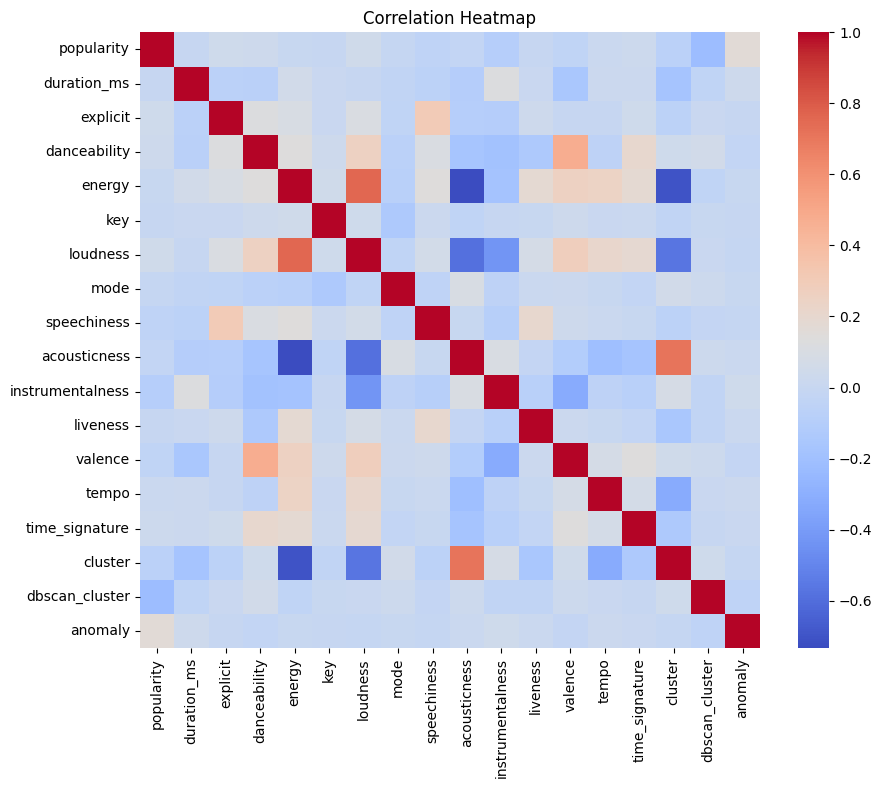

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Correlation Heatmap Interpretation

The correlation heatmap shows moderate relationships between features such as energy and loudness, and negative relationships between acousticness and energy. This indicates that certain musical properties are interconnected, which supports the use of dimensionality reduction techniques like PCA.

## Analytical Choices

K-Means clustering was selected as a baseline method due to its efficiency and ability to identify global cluster structures in numerical data. DBSCAN was applied to explore whether density-based clustering could better capture irregular or non-spherical groupings. However, DBSCAN produced many small clusters and noise points, suggesting the dataset lacks strong density separations.

Local Outlier Factor (LOF) was used to detect anomalies, as it identifies points that deviate from their local neighborhood density. This complements clustering by highlighting unusual songs that do not fit typical patterns.

PCA was applied both for dimensionality reduction and visualization. It helps reduce feature redundancy and allows for visual inspection of cluster structure in lower-dimensional space.

# Feature Selection

In [ ]:
# Feature Selection

features = [
"popularity",
"duration_ms",
"danceability",
"energy",
"loudness",
"speechiness",
"acousticness",
"instrumentalness",
"liveness",
"valence",
"tempo"
]

X = df[features]

# Feature Scaling

In [ ]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA (Dimensionality Reduction)

In [ ]:
# PCA (Dimensionality Reduction)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Variance explained by first two components:",
      explained_variance[0] + explained_variance[1])

Variance explained by first two components: 0.40000094834636757


# PCA Scatter Plot

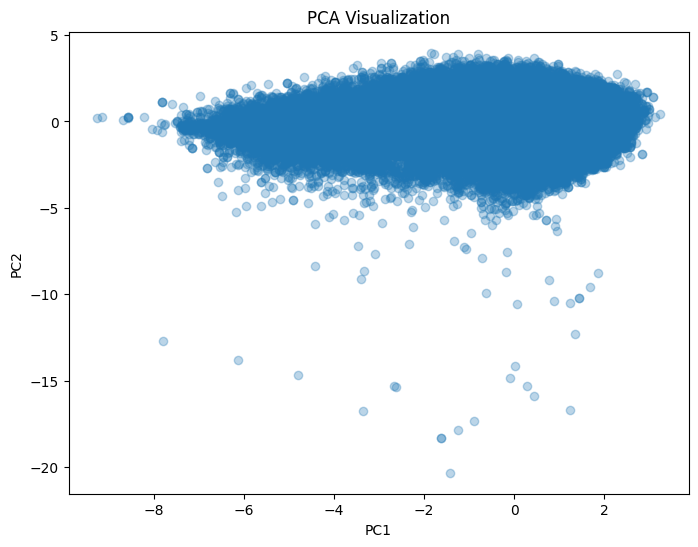

In [ ]:
# PCA Scatter Plot

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

# PCA Scatter Plot Interpretation

The first two principal components capture approximately 40% of the variance, indicating that while PCA reveals some underlying structure, a significant portion of variability remains in higher dimensions. This suggests that musical characteristics are distributed across multiple interacting features rather than dominated by a few dimensions.

# K-Means Clustering

In [ ]:
# K-Means Clustering

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Elbow Plot

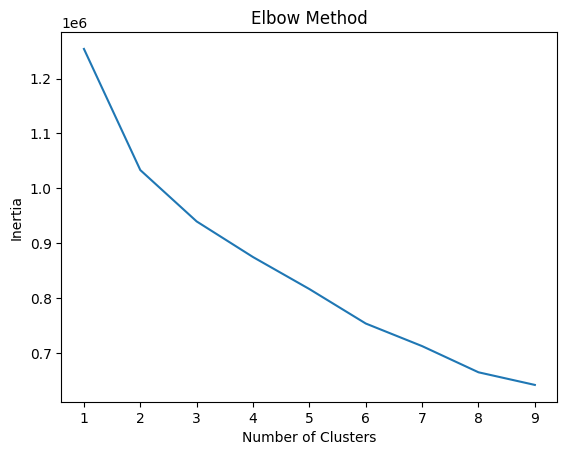

In [ ]:
# Elbow Plot

plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# K-Means Elbow Interpretation

The elbow plot suggests that k = 3 is a reasonable number of clusters, as the rate of decrease in inertia slows significantly after this point.

# K-Means Result Interpretation

K-Means clustering produced three clusters with some separation but noticeable overlap. This indicates that while there are groupings in the data, the boundaries between them are not sharply defined.

# Fit Final Model

In [ ]:
# Fit Final Model

kmeans = KMeans(n_clusters=3, random_state=42)

labels = kmeans.fit_predict(X_scaled)

df["cluster"] = labels

# Cluster Evaluation Metrics

In [ ]:
# Cluster Evaluation Metrics

sil = silhouette_score(X_scaled, labels)

db = davies_bouldin_score(X_scaled, labels)

ch = calinski_harabasz_score(X_scaled, labels)

print("Silhouette:", sil)
print("Davies-Bouldin:", db)
print("Calinski-Harabasz:", ch)

Silhouette: 0.13649831113007427
Davies-Bouldin: 2.1692954199892824
Calinski-Harabasz: 19068.7903804652


# Cluster Evaluation Metrics Interpretation

The silhouette score is relatively low, suggesting weak cluster separation. The Davies-Bouldin score indicates moderate overlap, while the Calinski-Harabasz score suggests reasonable cluster compactness. Overall, clustering performance is moderate.

# PCA Cluster Visualization

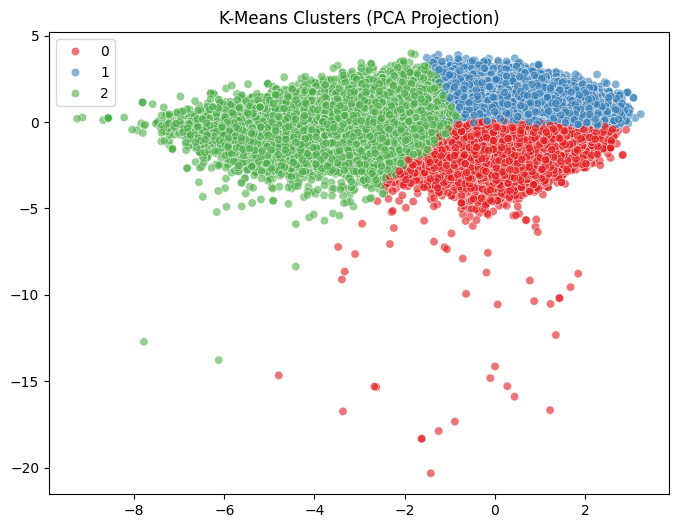

In [ ]:
# PCA Cluster Visualization

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=labels,
    palette="Set1",
    alpha=0.6
)
plt.title("K-Means Clusters (PCA Projection)")
plt.show()

This relatively low variance suggests that the dataset retains significant complexity in higher dimensions, which explains the overlapping clusters observed in the PCA projection.

# DBSCAN Clustering

In [ ]:
# DBSCAN Clustering

dbscan = DBSCAN(eps=0.7, min_samples=10)

db_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = db_labels

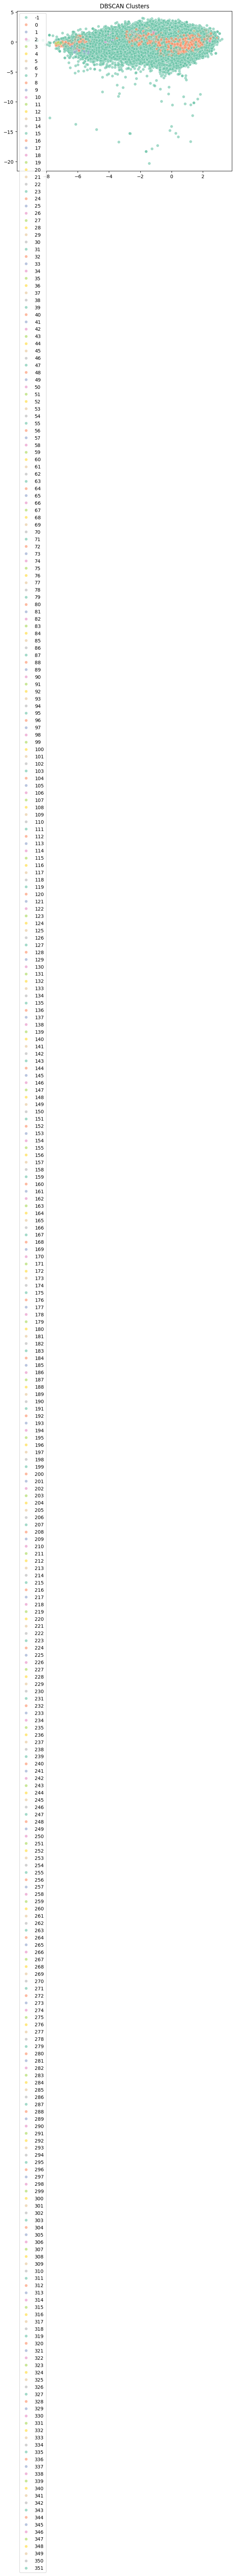

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=db_labels,
    palette="Set2",
    alpha=0.6
)
plt.title("DBSCAN Clusters")
plt.show()

# DBSCAN Clusters Interpretation

DBSCAN identified many small clusters and noise points, indicating that the dataset does not contain strong density-based clusters. This suggests that songs are more continuously distributed rather than forming dense groups.

This suggests that density-based clustering may not be well-suited for this dataset due to the lack of clear high-density separations.

# Anomaly Detection

In [ ]:
# Anomaly Detection

lof = LocalOutlierFactor(n_neighbors=20)

outliers = lof.fit_predict(X_scaled)

df["anomaly"] = outliers

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


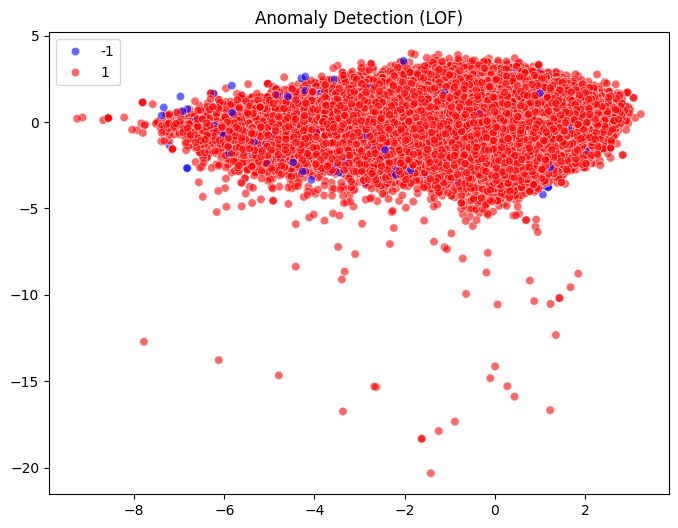

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=outliers,
    palette=["blue","red"],
    alpha=0.6
)
plt.title("Anomaly Detection (LOF)")
plt.show()

# Anomaly Detection (LOF) Interpretation

The LOF algorithm identified a small number of outliers, representing songs with unusual feature combinations. These anomalies may correspond to unique or experimental tracks.

These anomalies may represent niche or experimental songs that deviate from mainstream musical patterns.

# Cluster Interpretation

In [ ]:
cluster_means = df.groupby("cluster")[features].mean()

cluster_means

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,,,
0,35.102046,260523.012401,0.482665,0.798527,-6.109014,0.079121,0.089787,0.204403,0.253572,0.334453,135.117892
1,32.925877,209045.619719,0.682364,0.692101,-6.842003,0.103326,0.270941,0.042273,0.201673,0.664194,118.260497
2,30.898840,216201.296805,0.455252,0.279060,-14.763981,0.053606,0.772552,0.321549,0.174366,0.292479,109.527005


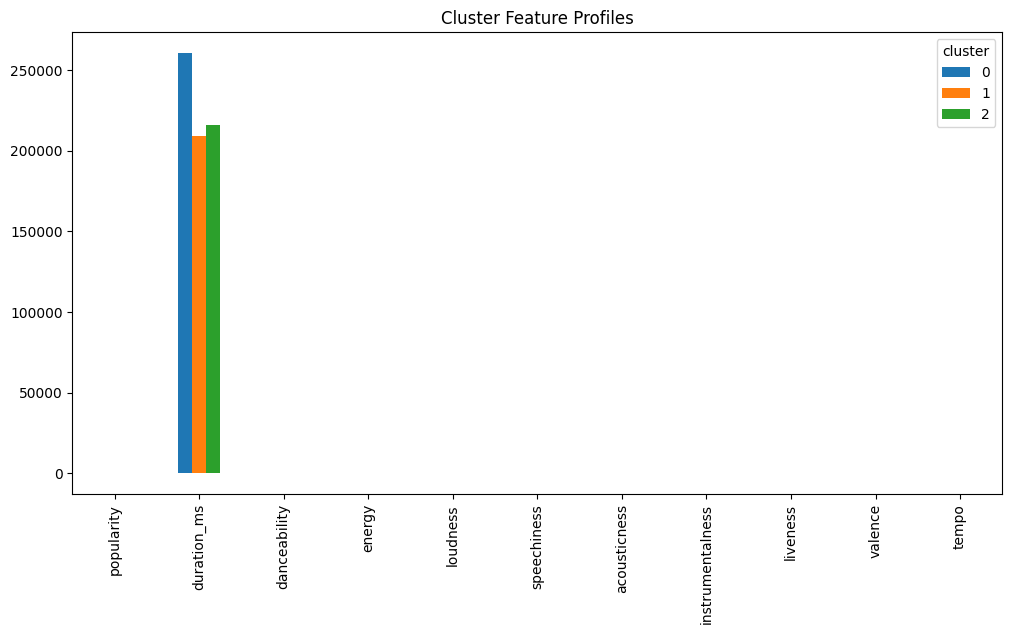

In [ ]:
cluster_means.T.plot(kind="bar", figsize=(12,6))
plt.title("Cluster Feature Profiles")
plt.show()

# Cluster Interpretation

The cluster means reveal distinct musical profiles:
- One cluster represents energetic and loud songs
- Another captures more danceable and positive tracks
- The third represents more acoustic and less energetic music

This confirms that clustering successfully captured meaningful differences in musical style.

# **Analysis**

The dataset consists of 114,000 Spotify tracks described by a range of audio features, including danceability, energy, loudness, acousticness, and tempo. After preprocessing and standardizing the selected numerical features, Principal Component Analysis (PCA) was applied to reduce dimensionality and enable visualization of latent musical structure.

The first two principal components explain approximately 40% of the total variance. While this indicates that PCA captures some meaningful structure, a substantial portion of variability remains in higher dimensions. This suggests that the dataset is inherently complex, which helps explain the overlapping clusters observed in the lower-dimensional projections.

K-Means clustering was used to identify natural groupings of songs. The elbow method suggested an optimal value of
𝑘
=
3
k=3, and evaluation metrics provided further insight into clustering quality:

Silhouette Score ≈ 0.136 (indicating weak separation between clusters)

Davies–Bouldin Score ≈ 2.17 (suggesting moderate cluster overlap)

Calinski–Harabasz Score ≈ 19068 (indicating reasonable dispersion)

Together, these metrics indicate that while clusters are present, they are not strongly separated. This suggests that musical characteristics exist on a continuum rather than forming sharply distinct categories.

Despite this overlap, cluster profiling revealed meaningful and interpretable patterns:

Cluster 0: Higher energy and loudness, representing energetic or upbeat tracks

Cluster 1: Higher danceability and valence, indicating more rhythmic and positive songs

Cluster 2: Higher acousticness and lower energy, representing calmer or acoustic tracks

To further explore clustering behavior, DBSCAN was applied as a density-based alternative. Unlike K-Means, DBSCAN identified many small clusters and noise points, indicating that the dataset does not contain well-defined dense regions. This highlights a key difference between the methods: K-Means captures broad, global structure, while DBSCAN attempts to identify dense local groupings. In this case, the results suggest that the data is better characterized by gradual transitions in musical features rather than distinct density-based clusters.

Finally, anomaly detection using Local Outlier Factor (LOF) identified a small number of outliers. These tracks exhibit unusual combinations of audio features and may represent rare or experimental music styles. However, due to the presence of duplicate values in the dataset, these results should be interpreted with some caution.

Overall, the analysis demonstrates that while structure exists in the data, it is not strictly separable, reflecting the continuous and nuanced nature of musical characteristics.

This reinforces the idea that musical styles are not strictly separated but instead form gradual transitions across features such as energy, tempo, and acousticness, reflecting the complexity of real-world music.

# **Conclusion**

This project demonstrates that unsupervised learning techniques can uncover meaningful latent structures within Spotify audio features, providing insight into how songs relate to one another based on their characteristics.

K-Means clustering successfully identified three broad categories of songs, corresponding to energetic, danceable, and acoustic musical profiles. However, the relatively low silhouette score and overlapping cluster boundaries indicate that these groupings are not sharply defined. Instead, the results suggest that musical attributes vary along continuous dimensions rather than forming discrete, well-separated classes.

Comparative analysis showed that K-Means was more effective than DBSCAN for this dataset. While K-Means captured overall structure in the data, DBSCAN struggled to identify coherent clusters due to the lack of strong density-based groupings. This reinforces the conclusion that the dataset is better represented by gradual variation rather than distinct clusters.

Additionally, anomaly detection using LOF highlighted a small subset of songs with unusual feature combinations. These anomalies may represent unique or unconventional tracks that fall outside typical musical patterns, offering potential areas for further exploration.

In conclusion, the findings support the idea that while machine learning techniques can reveal patterns in music data, musical structure is inherently complex and continuous. This makes strict clustering challenging, but still valuable for uncovering high-level trends and meaningful groupings.